Monte Carlo Simulation on Efficient Frontier

In [1]:
import pandas as pd
import  numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import datetime as dt
import yfinance as yf


In [2]:
stockList = ['PLTR', 'AAPL', 'TSLA', 
             'VICI', 'KO', 'NVDA', 
             'LMT', 'NOC', 'META']

# Set date range for historical data
endDate = dt.datetime.now()
startDate = endDate - dt.timedelta(days=365*10) # 5 years of data

In [3]:
# Import Data from  Yahoo Finance
def get_data(stocks, start, end):
    stockData = yf.download(stocks, start=start, end=end)
    stockData = stockData['Adj Close']
    return stockData


In [4]:
stockData = get_data(stockList, startDate, endDate)
stockData
# print(meanReturns)

[*********************100%***********************]  9 of 9 completed


Ticker,AAPL,KO,LMT,META,NOC,NVDA,PLTR,TSLA,VICI
Date,,,,,,,,,
2014-12-05,25.609850,31.673513,146.152420,76.130783,126.093735,0.505739,NaN,14.914000,NaN
2014-12-08,25.030838,31.389753,146.137100,76.290291,125.137520,0.499259,NaN,14.290667,NaN
2014-12-09,25.413874,30.589361,146.729828,76.609337,125.974190,0.497578,NaN,14.459333,NaN
2014-12-10,24.930632,30.269196,144.643707,75.951324,123.216507,0.486537,NaN,13.989333,NaN
2014-12-11,24.857143,30.218266,145.675217,77.496666,124.411781,0.486297,NaN,13.925333,NaN
...,...,...,...,...,...,...,...,...,...
2024-11-22,229.869995,63.438839,542.219971,559.140015,496.869995,141.949997,64.349998,352.559998,32.230000
2024-11-25,232.869995,63.895374,521.890015,565.109985,485.269989,136.020004,64.650002,338.589996,32.529999
2024-11-26,235.059998,64.064102,521.450012,573.539978,488.429993,136.919998,65.739998,338.230011,32.380001


In [5]:
from sklearn.model_selection import train_test_split

# Prepare data
X = stockData.dropna()
y = stockData.dropna()

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.15, shuffle=False)

print('Training Data Dimension: ', X_train.shape)
print('Testing Data Dimension: ', X_test.shape)

Training Data Dimension:  (891, 9)
Testing Data Dimension:  (158, 9)


In [9]:
returns = X_train.pct_change().dropna() # Daily Return
returns.columns = stockList 
annualAverageReturns = pd.DataFrame(returns.mean()*252)

dailyAvgReturn = returns + 1 # Portfolio Returns day to day

# Calculate Geo Mean
cumulativeReturnFactors = dailyAvgReturn.prod() # Calculate the cumulative return factors
n_periods = dailyAvgReturn.shape[0] # Determine the number of periods


geometricAvgReturnDaily = cumulativeReturnFactors ** (1 / n_periods) - 1 # Calculate the Geo mean daily return

geometricAvgReturnDaily = pd.DataFrame(data=geometricAvgReturnDaily, columns=['Geometric Average Daily Return'])  # Convert to DataFrame

# Assuming 252 trading days in a year
geometricAvgReturnAnnual = (1 + geometricAvgReturnDaily['Geometric Average Daily Return']) ** 252 - 1 # Annualize the Geo mean return

geometricAvgReturnDaily['Annualized Geometric Average Return'] = geometricAvgReturnAnnual.values

combined_returns = pd.concat(
    [annualAverageReturns, geometricAvgReturnDaily['Annualized Geometric Average Return']],
    axis=1
)
combined_returns.columns = ['Arithmetic Average Annual Return', 'Geometric Average Annual Return']

combined_returns
#print('Returns: ', dailyAvgReturn)
#print('Geo Daily/Geo Annual: ', geometric_avg_return_daily)
#print('Combined Returns: ', combined_returns)


,Arithmetic Average Annual Return,Geometric Average Annual Return
PLTR,0.152333,0.120143
AAPL,0.089682,0.079194
TSLA,0.097984,0.078466
VICI,0.292609,0.201126
KO,0.146697,0.124095
NVDA,0.661379,0.697244
LMT,0.499937,0.266457
NOC,0.194829,0.026996
META,0.119876,0.096310


In [234]:
# Sharp Ratio Implementation

In [235]:
sharpeRatio = []
portfolioVolatility = []
portfolioReturns = []

stockWeights = []

# No. of Individual Stocks In Portfolio
numStock = len(stockList)

# No. Simulations
numSim = 10000

# Return Variables (from above)
returns = X_train.pct_change().dropna() # Daily Return
returns.columns = stockList 
annualAverageReturns = pd.DataFrame(returns.mean()*252) + 1

# CoVAR Matrix
covarDaily = returns.cov()
covAnnual = covarDaily*252

#print(annualAverageReturns)
print(covAnnual)

          PLTR      AAPL      TSLA  ...       LMT       NOC      META
PLTR  0.077908  0.015756  0.010061  ...  0.077337  0.081273  0.026132
AAPL  0.015756  0.026881  0.011614  ... -0.000280  0.009246  0.014328
TSLA  0.010061  0.011614  0.044750  ...  0.002136  0.006606  0.012202
VICI  0.068616  0.010616  0.004645  ...  0.116069  0.091004  0.029520
KO    0.008303  0.012539  0.038999  ...  0.000311  0.004116  0.014713
NVDA  0.085160  0.010981  0.000359  ...  0.166901  0.147835  0.034081
LMT   0.077337 -0.000280  0.002136  ...  0.543405  0.198037  0.043585
NOC   0.081273  0.009246  0.006606  ...  0.198037  0.336879  0.042185
META  0.026132  0.014328  0.012202  ...  0.043585  0.042185  0.055860

[9 rows x 9 columns]


In [236]:
# Calculations & Simulations
np.random.seed(3)

# Start filling in lists from above cell: 'sharpe_ratio', 'portfolio_volatility', 'portfolio_returns'.count

for i in range(numSim):
    # Random Weightss
    weights = np.random.random(numStock)    
    # Standardize
    weights /= np.sum(weights)
    new_returns = (np.dot(weights, (annualAverageReturns)))

    # Volatility Calculation
    volatility = np.sqrt(np.dot(weights.T, np.dot(covAnnual, weights)))

    # Sharpe Ratio
    sharpe = ((new_returns-1) / volatility)
    sharpeRatio.append(sharpe.item())
    
    # Portfolio  Returns
    portfolioReturns.append((new_returns-1).item())
    portfolioVolatility.append(volatility.item())
    stockWeights.append(weights)



In [237]:
portfolio = {'Returns': portfolioReturns,
             'Volatility': portfolioVolatility,
             'Sharpe Ratio': sharpeRatio
             }

for counter, symbol in enumerate(stockList):
    portfolio[symbol + ' Weight'] = [Weight[counter] for Weight in stockWeights]
    # print(counter, symbol)

port_df = pd.DataFrame(portfolio)
port_df


,Returns,Volatility,Sharpe Ratio,PLTR Weight,AAPL Weight,TSLA Weight,VICI Weight,KO Weight,NVDA Weight,LMT Weight,NOC Weight,META Weight
0,0.273605,0.222546,1.229433,0.130083,0.167244,0.068703,0.120643,0.210889,0.211679,0.029660,0.048945,0.012155
1,0.313003,0.276674,1.131307,0.118974,0.008064,0.123298,0.175203,0.075163,0.182520,0.159473,0.006473,0.150834
2,0.241445,0.276473,0.873302,0.066823,0.106994,0.073080,0.178659,0.113529,0.040433,0.140386,0.201129,0.078966
3,0.304649,0.270316,1.127012,0.041001,0.071668,0.172972,0.180290,0.124205,0.166775,0.156230,0.069824,0.017035
4,0.234814,0.215976,1.087224,0.176978,0.151093,0.097931,0.060957,0.110107,0.127014,0.072923,0.079033,0.123966
...,...,...,...,...,...,...,...,...,...,...,...,...
9995,0.276963,0.271681,1.019444,0.129807,0.108077,0.031546,0.036462,0.132937,0.148218,0.145439,0.152467,0.115046
9996,0.295817,0.322036,0.918585,0.118131,0.013668,0.040442,0.227631,0.007148,0.164255,0.075815,0.215270,0.137639
9997,0.214043,0.268292,0.797800,0.148915,0.138695,0.181743,0.018629,0.072611,0.021549,0.168161,0.223536,0.026161
9998,0.173216,0.190393,0.909781,0.100145,0.101163,0.227889,0.022207,0.139529,0.042685,0.046015,0.132780,0.187586


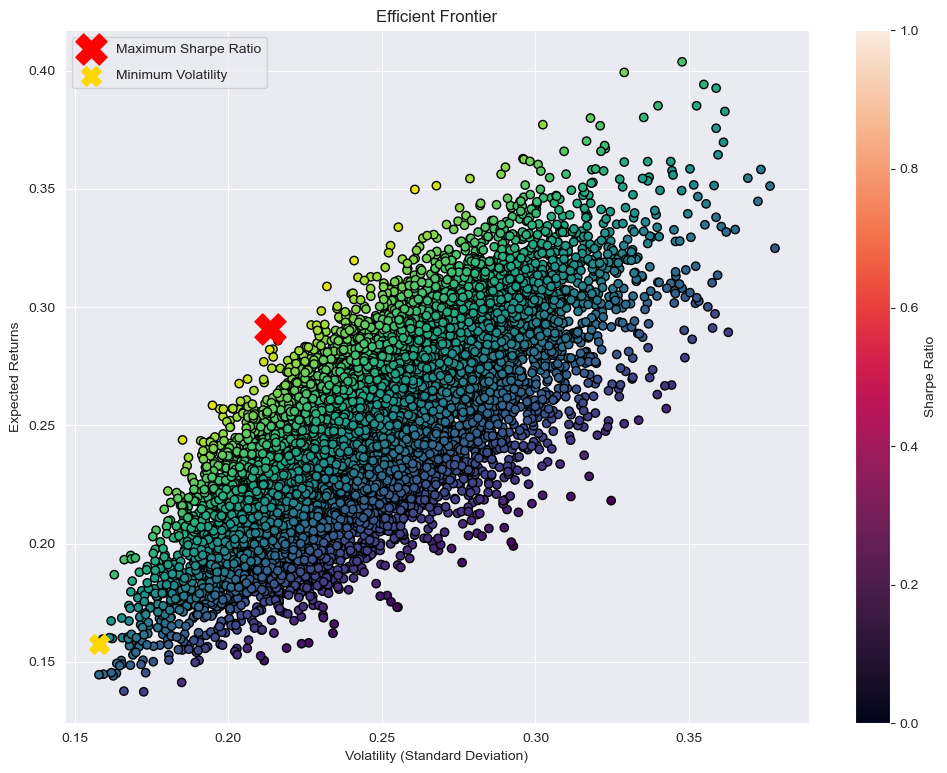

In [242]:
from scipy.optimize import minimize

# Identify Min and Max Risk portfolios
maxSharpePort = port_df.loc[port_df['Sharpe Ratio'].idxmax()]
minVolPort = port_df.loc[port_df['Volatility'].idxmin()]

# Plot Efficient Frontier!!!
sns.set_style('darkgrid')
plt.figure(figsize=(12, 9))

plt.scatter(
    x=port_df['Volatility'],
    y=port_df['Returns'],
    c=port_df['Sharpe Ratio'],
    cmap='viridis',
    edgecolors='black',
)

plt.scatter(
    maxSharpePort['Volatility'],
    maxSharpePort['Returns'],
    marker='X',
    color='r',
    s=500,
    label='Maximum Sharpe Ratio'
)

plt.scatter(
    minVolPort['Volatility'],
    minVolPort['Returns'],
    marker='X',
    color='gold',
    s=200,
    label='Minimum Volatility'
)

cbar = plt.colorbar()
cbar.set_label('Sharpe Ratio')

plt.title('Efficient Frontier')
plt.xlabel('Volatility (Standard Deviation)')
plt.ylabel('Expected Returns')
plt.legend(labelspacing=1)
plt.show()


In [243]:
risk_ef = pd.concat([minVolPort.T, maxSharpePort.T], axis=1)
risk_ef.columns = ['Minimum Risk Adjusted Values', 'Maximum Risk Adjusted Values']

print(risk_ef)

              Minimum Risk Adjusted Values  Maximum Risk Adjusted Values
Returns                           0.157444                      0.290801
Volatility                        0.157810                      0.213699
Sharpe Ratio                      0.997680                      1.360798
PLTR Weight                       0.089141                      0.000475
AAPL Weight                       0.205226                      0.192039
TSLA Weight                       0.231030                      0.143971
VICI Weight                       0.036196                      0.055070
KO Weight                         0.158349                      0.235559
NVDA Weight                       0.034390                      0.235846
LMT Weight                        0.041061                      0.094005
NOC Weight                        0.016037                      0.007881
META Weight                       0.188571                      0.035154


In [ ]:
amountInvest = 1000
expectedReturn = pd.DataFrame(amountInvest * (1+risk_ef.iloc[0,:]))
print("----------------------------------------------------------------")
print("                Expected Returns on Portfolio")
print("----------------------------------------------------------------")
print(expectedReturn.T)
print("")
print("----------------------------------------------------------------")
print("If I invested", amountInvest,"USD on |", X_train.index[0],"| I would have...")
actual_return = (X_train.iloc[X_train.shape[0]-1,:] - X_train.iloc[0,:]) / ( X_train.iloc[0,:])
# Multipling the weights to the price at the beginning of the year
beg_price = (X_train.iloc[0,:])
end_price = X_train.iloc[X_train.shape[0]-1,:]
print("----------------------------------------------------------------")
# Weights derived from the Efficient Frontier Portfolio
# Weights for Minimum Risk
w = np.array(risk_ef.iloc[3:,0])
percentage_change = (end_price - beg_price)/(beg_price)+1
print("Using the Portfolio Weights for Minimum Risk Return Portfolio")
money_left = sum(w * percentage_change* amountInvest)
print("")
print("    Starting balance $ 1000 : Ending with $ ",round(money_left, 2))
print("")
print("----------------------------------------------------------------")
print("Using the Portfolio Weights Maximized Risk-Return Portfolio")
# Weights for Maxmimum Risk
w1 = np.array(risk_ef.iloc[3:,1])

money_left1 = sum(w1 * percentage_change* amountInvest)
print("")
print("    Starting balance $ 1000 : Ending with $ ", round(money_left1,2))
print("")


----------------------------------------------------------------
                Expected Returns on Portfolio
----------------------------------------------------------------
         Minimum Risk Adjusted Values  Maximum Risk Adjusted Values
Returns                    1157.44427                   1290.801222

----------------------------------------------------------------


In [273]:
amountInvest = 5000

expectedReturn = pd.DataFrame(amountInvest * (1 + risk_ef.iloc[0, :]))

print("Expected Returns on Portfolio:")
print(expectedReturn.T)

Expected Returns on Portfolio:
         Minimum Risk Adjusted Values  Maximum Risk Adjusted Values
Returns                   5787.221349                   6454.006109


In [274]:
# Calculate the actual returns for each stock
begPrice = X_train.iloc[0, :]
endPrice = X_train.iloc[-1, :]
actualReturn = (endPrice - begPrice) / begPrice
percentageChange = actualReturn + 1

In [275]:
# STock Minimum Return
weightMin = np.array(risk_ef.iloc[3:, 0])
moneyLeftMin = sum(weightMin * percentage_change * amountInvest)

print("Using the Portfolio Weights for Minimum Risk Return Portfolio:")
print(f"Starting balance $ {amountInvest} : Ending with $ {round(moneyLeftMin, 2)}")

Using the Portfolio Weights for Minimum Risk Return Portfolio:
Starting balance $ 5000 : Ending with $ 8038.61


In [276]:
weightMax = np.array(risk_ef.iloc[3:, 1])
moneyLeftMax = sum(weightMax * percentageChange * amountInvest)

print("Using the Portfolio Weights for Maximized Risk-Return Portfolio:")
print(f"Starting balance $ {amountInvest} : Ending with $ {round(moneyLeftMax, 2)}")

Using the Portfolio Weights for Maximized Risk-Return Portfolio:
Starting balance $ 5000 : Ending with $ 13513.91


In [281]:
print('Stock Weights for Investment: ')
print("")
print(risk_ef.iloc[3:, :])

Stock Weights for Investment: 

             Minimum Risk Adjusted Values  Maximum Risk Adjusted Values
PLTR Weight                      0.089141                      0.000475
AAPL Weight                      0.205226                      0.192039
TSLA Weight                      0.231030                      0.143971
VICI Weight                      0.036196                      0.055070
KO Weight                        0.158349                      0.235559
NVDA Weight                      0.034390                      0.235846
LMT Weight                       0.041061                      0.094005
NOC Weight                       0.016037                      0.007881
META Weight                      0.188571                      0.035154
